<a href="https://colab.research.google.com/github/kyuho11488/kyuho11488/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC20250613_2021148025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **기말고사(20250613)**
학번 : 2021148025
성명 : 이규호

# **문제 1) ANN Backpropagation**

In [2]:
# Back-propagation of ANN with numpy
import numpy as np
import matplotlib.pyplot as plt

# Data Generation
np.random.seed(0)
num_samples = 300

x1 = np.random.uniform(0, 1, num_samples)
x2 = np.random.uniform(0, 1, num_samples)
x3 = np.random.uniform(0, 1, num_samples)

# Combine the features into a Numpy array
Input = np.column_stack((x1, x2, x3))

# Target
y = 3 * x1 - 2 * x2 + x3

<ipython-input-3-1217582052>:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W1[0][0] += -alpha * dJdW1_11
<ipython-input-3-1217582052>:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W1[0][1] += -alpha * dJdW1_12
<ipython-input-3-1217582052>:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W1[0][2] += -alpha * dJdW1_13
<ipython-input-3-1217582052>:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future.

MSE and MAPE at epoch  0  : 0.597956169289457  , 323.28579300699727
MSE and MAPE at epoch  5  : 0.5937604984484672  , 305.96735426332384
MSE and MAPE at epoch  10  : 0.5914245534931676  , 304.8591991379675
MSE and MAPE at epoch  15  : 0.5887971699503749  , 304.40593602306456
MSE and MAPE at epoch  20  : 0.5857928396185544  , 303.90173306287716
MSE and MAPE at epoch  25  : 0.5823075518462787  , 303.28863956039004
MSE and MAPE at epoch  30  : 0.5782200187218522  , 302.5346641521856
MSE and MAPE at epoch  35  : 0.5733880216531768  , 301.59826608329024
MSE and MAPE at epoch  40  : 0.5676442335519285  , 300.43046138618575
MSE and MAPE at epoch  45  : 0.5607923593035705  , 298.9721558214422
MSE and MAPE at epoch  50  : 0.552604532167828  , 297.1516479157879
MSE and MAPE at epoch  55  : 0.5428215505977766  , 294.8848798365961
MSE and MAPE at epoch  60  : 0.5311583532810928  , 292.0753776903588
MSE and MAPE at epoch  65  : 0.5173178210042059  , 288.60481534472854
MSE and MAPE at epoch  70  : 0

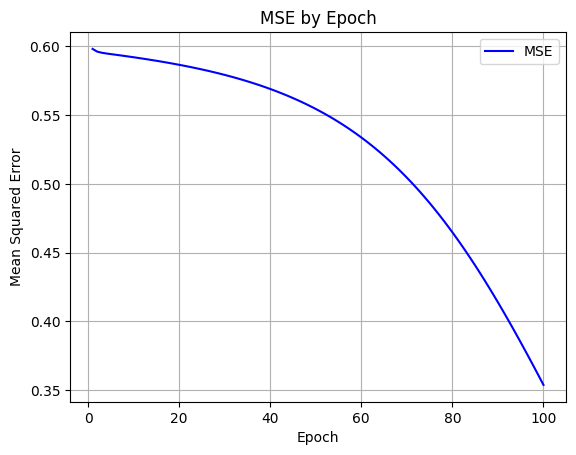

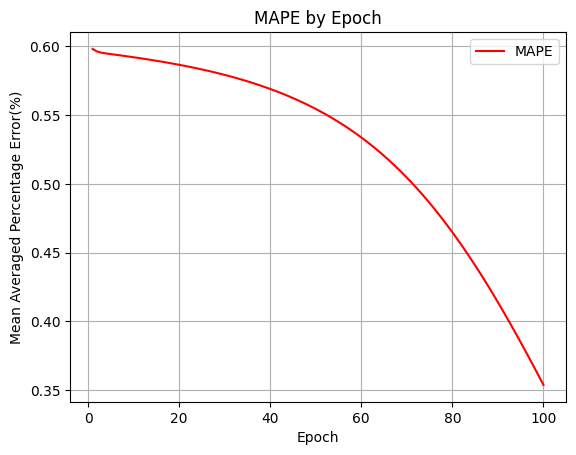

In [3]:
# Sigmoid function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

# Network parameters
input_layer_size = 3  # Input layer neurons
hidden_layer_size = 2  # Hidden layer neurons
output_layer_size = 1  # Output layer neurons

# Weights and biases
W1 = np.random.rand(hidden_layer_size, input_layer_size)
b1 = np.random.rand(hidden_layer_size)
W2 = np.random.rand(output_layer_size, hidden_layer_size)
b2 = np.random.rand(output_layer_size)

alpha = 0.001 #learning rate
epochs = 100
MSE_list, MAPE_list = [], []
for epoch in range(epochs):
    MSE, MAPE = 0,0
    for iter in range(num_samples):
        X = Input[iter]
        # Feedforward
        Z_tilde = W1@X.reshape(-1,1)+ b1.reshape(-1,1)
        Z = sigmoid(Z_tilde)
        y_pred = W2@Z.reshape(-1,1) + b2.reshape(-1,1)

        # Calculating the error
        J = 1/2*(y_pred-y[iter])**2
        MSE += J
        MAPE += np.abs((y_pred-y[iter])/y[iter])*100

        # Backpropagation
        # Output layer --> hidden layer
        dJdY = (y_pred-y[iter])
        dJdW2_11, dJdW2_12 = dJdY*Z[0], dJdY*Z[1]
        dJdb2_1 = dJdY
        dJdZ1, dJdZ2 = dJdY*W2[0,0], dJdY*W2[0,1]

        # Hidden layer --> Input layer
        dJdW1_11 = dJdZ1 * X[0] * sigmoid_derivative(Z_tilde[0])
        dJdW1_12 = dJdZ1 * X[1] * sigmoid_derivative(Z_tilde[0])
        dJdW1_13 = dJdZ1 * X[2] * sigmoid_derivative(Z_tilde[0])
        dJdW1_21 = dJdZ2 * X[0] * sigmoid_derivative(Z_tilde[1])
        dJdW1_22 = dJdZ2 * X[1] * sigmoid_derivative(Z_tilde[1])
        dJdW1_23 = dJdZ2 * X[2] * sigmoid_derivative(Z_tilde[1])
        dJdb1_1 = dJdZ1 * sigmoid_derivative(Z_tilde[0])
        dJdb1_2 = dJdZ2 * sigmoid_derivative(Z_tilde[1])
        # Update
        W1[0][0] += -alpha * dJdW1_11
        W1[0][1] += -alpha * dJdW1_12
        W1[0][2] += -alpha * dJdW1_13
        W1[1][0] += -alpha * dJdW1_21
        W1[1][1] += -alpha * dJdW1_22
        W1[1][2] += -alpha * dJdW1_23
        b1[0] += -alpha * dJdb1_1
        b1[1] += -alpha * dJdb1_2
        W2[0][0] += -alpha * dJdW2_11
        W2[0][1] += -alpha * dJdW2_12
        b2[0] += -alpha*dJdb2_1
    MSE, MAPE = MSE/num_samples, MAPE/num_samples
    MSE_list.append(np.squeeze(MSE))
    MAPE_list.append(np.squeeze(MAPE))
    if epoch % 5 == 0 or epoch == epochs-1:
       print('MSE and MAPE at epoch ', epoch, ' :',
             np.squeeze(MSE), ' ,', np.squeeze(MAPE))

plt.figure()
plt.plot(np.arange(1,epochs+1), MSE_list, label='MSE', linewidth=1.5, color='b')
#plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('MSE by Epoch')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(np.arange(1,epochs+1), MSE_list, label='MAPE', linewidth=1.5, color='r')
#plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Mean Averaged Percentage Error(%)')
plt.title('MAPE by Epoch')
plt.legend()
plt.grid(True)
plt.show()

# **문제 2) CNN**
- Data
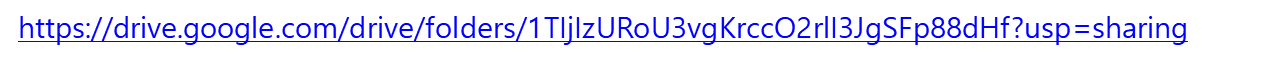

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score

# 0,1,2,3,4, and 5 finger image data set

train_x = np.load('/content/drive/MyDrive/Colab Notebooks/Finger_train_img.npy')
train_y = np.load('/content/drive/MyDrive/Colab Notebooks/Finger_train_label.npy')

test_x = np.load('/content/drive/MyDrive/Colab Notebooks/Finger_test_img.npy')
test_y = np.load('/content/drive/MyDrive/Colab Notebooks/Finger_test_label.npy')

In [29]:
# 2. 정규화하기
train_x = train_x / 255.0
test_x = test_x / 255.0

# 3. 모델 구성하기
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')  # 6-class 분류하기
])

# 4. 컴파일하기
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. 학습하기
model.fit(train_x, train_y,
          validation_split=0.1,
          epochs=20,
          batch_size=32)

# 6. 평가 및 예측하기
loss, acc = model.evaluate(test_x, test_y)
print(f"Test Accuracy: {acc * 100:.2f}%")

# 7. 예측 결과 출력하기
y_pred = model.predict(test_x)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(test_y, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels))

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 299ms/step - accuracy: 0.1849 - loss: 2.3219 - val_accuracy: 0.0000e+00 - val_loss: 2.3535
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.5153 - loss: 1.5640 - val_accuracy: 0.0000e+00 - val_loss: 1.7520
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.7888 - loss: 0.6953 - val_accuracy: 0.7111 - val_loss: 0.6780
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 293ms/step - accuracy: 0.8814 - loss: 0.3632 - val_accuracy: 0.9000 - val_loss: 0.3450
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 293ms/step - accuracy: 0.9239 - loss: 0.2318 - val_accuracy: 0.9444 - val_loss: 0.1821
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 0.9497 - loss: 0.1990 - val_accuracy: 0.8667 - val_loss: 0.3469
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 275ms/step - accuracy: 0.9621 - loss: 0.1225 - val_accuracy: 0.9667 - val_loss: 0.0885
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - accuracy: 0.9769 - loss: 0.1035 - val_accuracy: 0.

# **문제 3) K-means clustering**

In [22]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
data1 = np.array((np.random.normal(0, 0.2, 100), np.random.normal(0.0, 0.4, 100)))
data2 = np.array((np.random.normal(1.2, 0.3, 100), np.random.normal(1.1, 0.7, 100)))
data3 = np.array((np.random.normal(1.6, 0.2, 100), np.random.normal(1.8, 0.7, 100)))
data4 = np.array((np.random.normal(0.3, 0.1, 100), np.random.normal(0.5, 0.3, 100)))

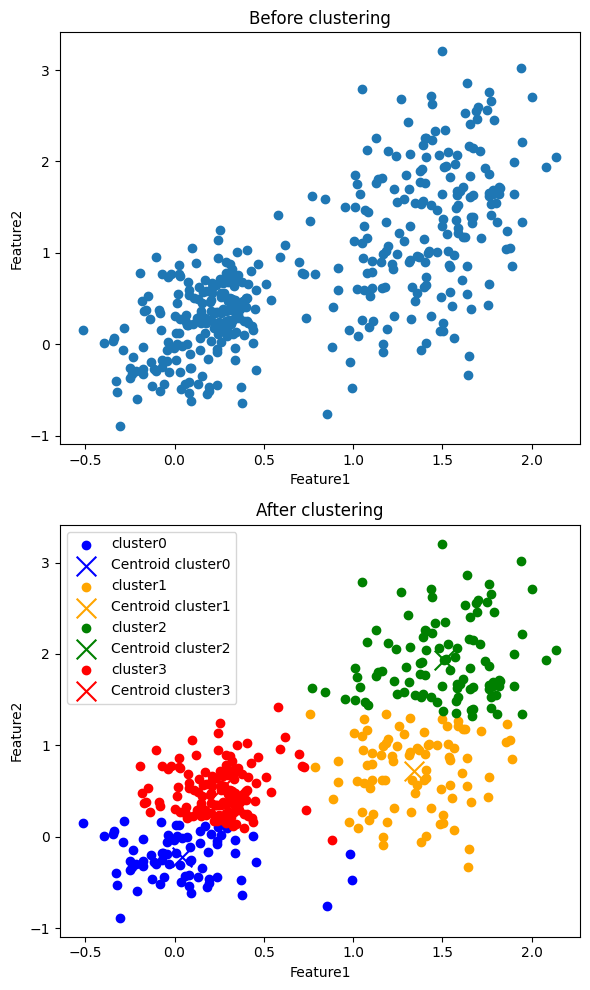

In [24]:
data = np.hstack((data1, data2, data3, data4)).T

# 초기 중심 설정하기
init_centroids = np.array([
    data1.mean(axis=1),
    data2.mean(axis=1),
    data3.mean(axis=1),
    data4.mean(axis=1)
])

# K-means 함수 정의하기
def kmeans(X, K, centroids, max_iter=100):
    for _ in range(max_iter):
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])
        if np.allclose(centroids, new_centroids): break
        centroids = new_centroids
    return centroids, labels

# K=4 기준으로 실행하기
K = 4
final_centroids, final_labels = kmeans(data, K, init_centroids)

# 시각화하기 (Before + After)
fig, axes = plt.subplots(2, 1, figsize=(6, 10))

# Before
axes[0].scatter(data[:, 0], data[:, 1])
axes[0].set_title("Before clustering")
axes[0].set_xlabel("Feature1")
axes[0].set_ylabel("Feature2")

# After
colors = ['blue', 'orange', 'green', 'red']
for k in range(K):
    cluster_points = data[final_labels == k]
    axes[1].scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[k], label=f'cluster{k}')
    axes[1].scatter(final_centroids[k][0], final_centroids[k][1],
                    marker='x', s=200, color=colors[k], label=f'Centroid cluster{k}')
axes[1].set_title("After clustering")
axes[1].set_xlabel("Feature1")
axes[1].set_ylabel("Feature2")
axes[1].legend()
plt.tight_layout()
plt.show()